       CLASSIFICATION TASK - TITANIC DATASET
                Register No: 24EU02039

1. FIRST 5 ROWS
--------------------------------------------------
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

2. PREPROCESSED DATA
-------------------

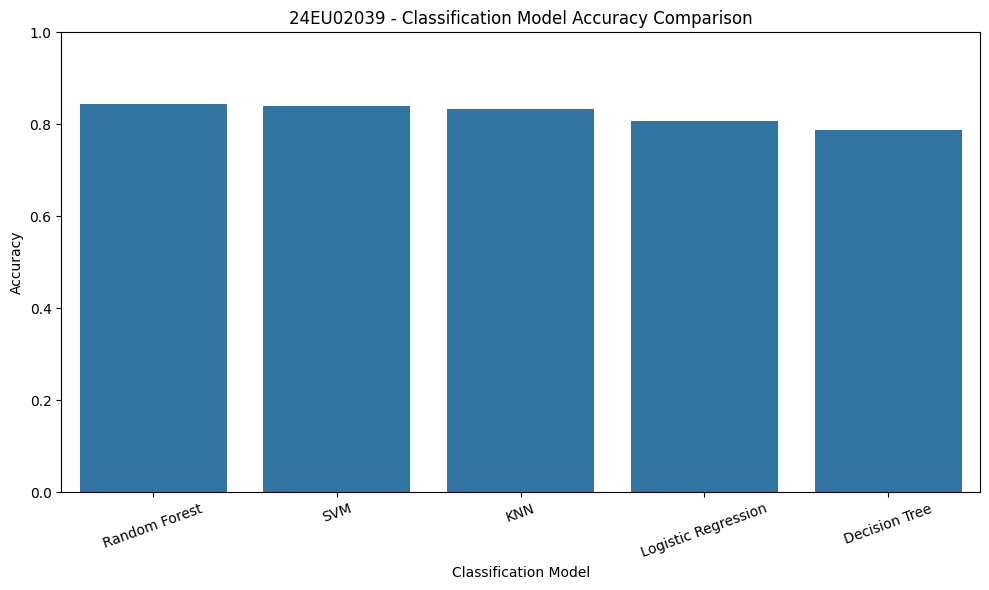

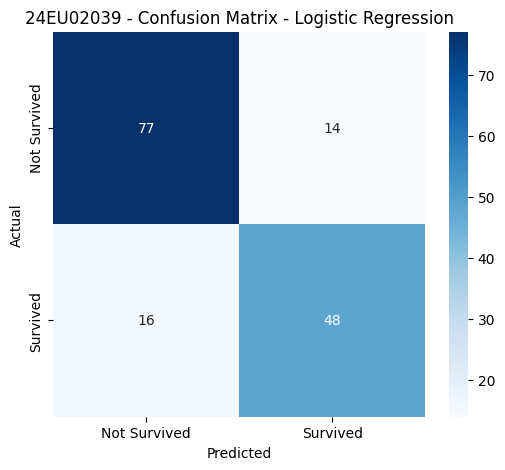

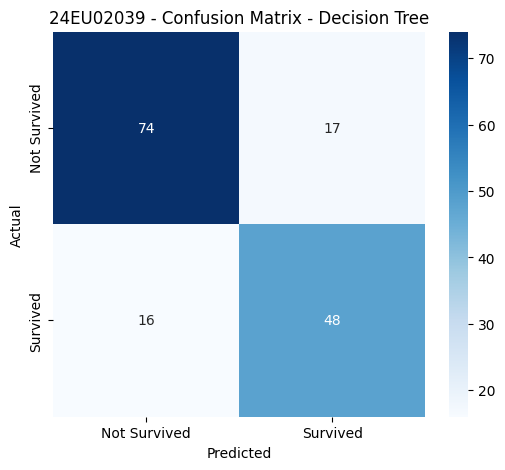

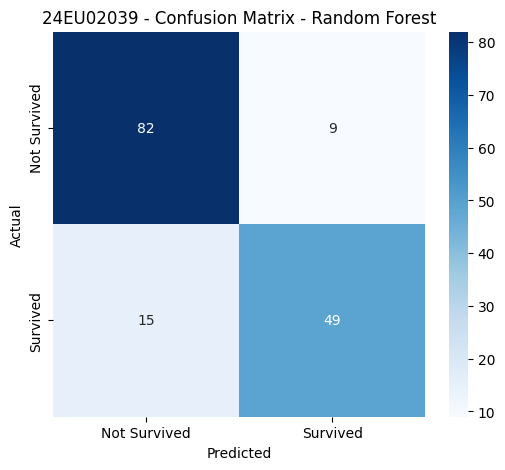

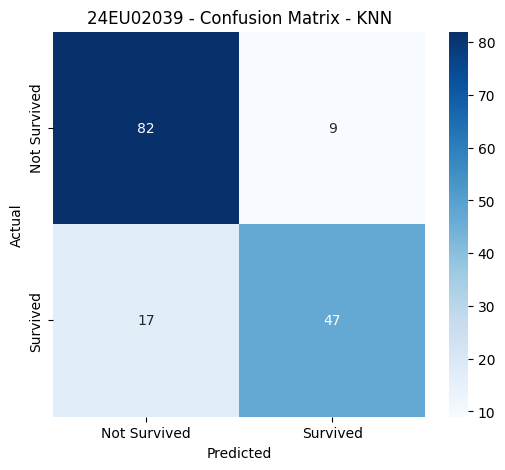

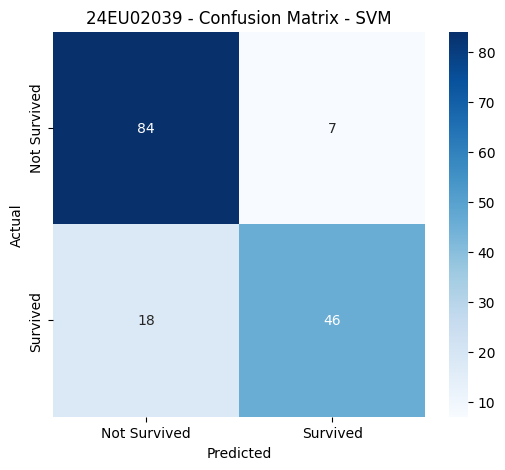



CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84        91
    Survived       0.77      0.75      0.76        64

    accuracy                           0.81       155
   macro avg       0.80      0.80      0.80       155
weighted avg       0.81      0.81      0.81       155



CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

Not Survived       0.82      0.81      0.82        91
    Survived       0.74      0.75      0.74        64

    accuracy                           0.79       155
   macro avg       0.78      0.78      0.78       155
weighted avg       0.79      0.79      0.79       155



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87        91
    Survived       0.84      0.77      0.80        64

    accuracy                           0.85       155
  

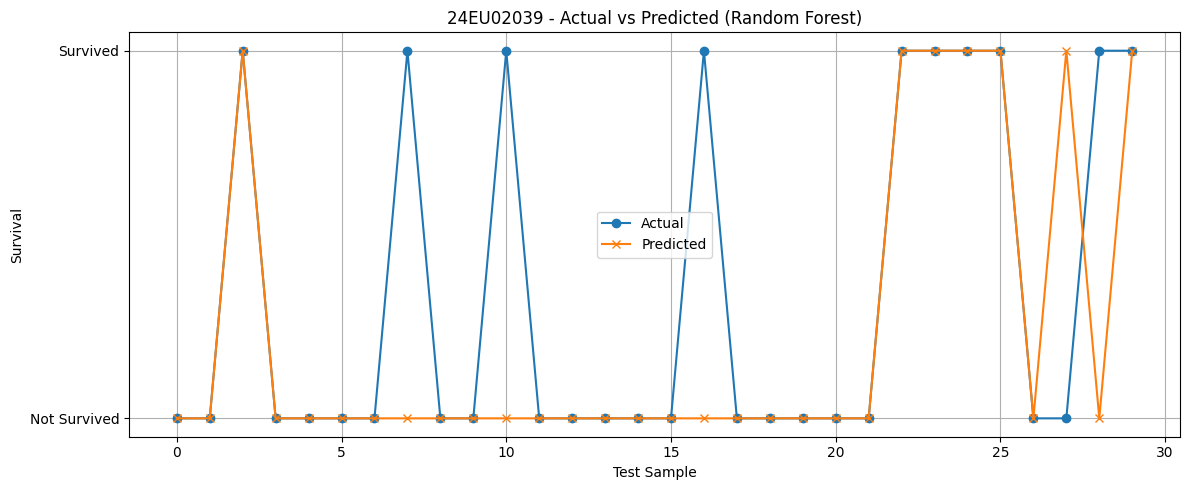



                         CONCLUSION

The Titanic dataset was used for binary classification.

Target:
survived

0 = Not Survived
1 = Survived

Classification algorithms used:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

The data was preprocessed by handling missing values,
encoding categorical variables, creating new features,
removing duplicates and scaling numerical features.

The best performing model was:
Random Forest

Accuracy:
84.52%

       TITANIC CLASSIFICATION COMPLETED
                 24EU02039


In [2]:
# ============================================================
#       CLASSIFICATION TASK - TITANIC DATASET
#       Register Number: 24EU02039
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("       CLASSIFICATION TASK - TITANIC DATASET")
print("                Register No: 24EU02039")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = sns.load_dataset('titanic')

print("\n1. FIRST 5 ROWS")
print("-" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)


# ------------------------------------------------------------
# 2. PREPROCESSING
# ------------------------------------------------------------

# Remove unnecessary columns
df.drop(
    columns=['deck', 'alive', 'embark_town'],
    inplace=True,
    errors='ignore'
)

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Create new features
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Encode gender
df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})

# One-hot encode embarked and other categorical columns
df = pd.get_dummies(
    df,
    columns=['embarked', 'class', 'who'], # Added 'class' and 'who'
    drop_first=True,
    dtype=int
)

# Convert boolean columns to integer
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\n2. PREPROCESSED DATA")
print("-" * 50)
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 3. FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop('survived', axis=1)
y = df['survived']

print("\n3. FEATURES")
print("-" * 50)
print(X.columns.tolist())

print("\nTarget: survived")


# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n4. TRAIN-TEST SPLIT")
print("-" * 50)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 5. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. CREATE CLASSIFICATION MODELS
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel='rbf',
        random_state=42
    )
}


# ------------------------------------------------------------
# 7. TRAIN AND EVALUATE MODELS
# ------------------------------------------------------------

results = []
predictions = {}

print("\n")
print("=" * 70)
print("                    MODEL ACCURACY")
print("=" * 70)

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    predictions[name] = y_pred

    print(
        f"{name:<25}: {accuracy * 100:.2f}%"
    )


# ------------------------------------------------------------
# 8. MODEL COMPARISON
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\nMODEL COMPARISON")
print("-" * 50)
print(results_df)


# ------------------------------------------------------------
# 9. GRAPH - MODEL ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title(
    '24EU02039 - Classification Model Accuracy Comparison'
)

plt.xlabel('Classification Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. CONFUSION MATRICES
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Survived', 'Survived'],
        yticklabels=['Not Survived', 'Survived']
    )

    plt.title(
        f'24EU02039 - Confusion Matrix - {name}'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


# ------------------------------------------------------------
# 11. CLASSIFICATION REPORTS
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    print("\n")
    print("=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Not Survived',
                'Survived'
            ]
        )
    )


# ------------------------------------------------------------
# 12. BEST MODEL
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']

print("\n")
print("=" * 70)
print("                       BEST MODEL")
print("=" * 70)

print("Best Model :", best_model_name)
print("Accuracy   :", f"{best_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# 13. ACTUAL VS PREDICTED
# ------------------------------------------------------------

best_predictions = predictions[best_model_name]

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_predictions
})

print("\nACTUAL VS PREDICTED")
print("-" * 50)
print(comparison.head(20))


# ------------------------------------------------------------
# 14. GRAPH - ACTUAL VS PREDICTED
# ------------------------------------------------------------

sample = comparison.head(30)

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(sample)),
    sample['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(sample)),
    sample['Predicted'],
    marker='x',
    label='Predicted'
)

plt.title(
    f'24EU02039 - Actual vs Predicted ({best_model_name})'
)

plt.xlabel('Test Sample')
plt.ylabel('Survival')

plt.yticks(
    [0, 1],
    ['Not Survived', 'Survived']
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. CONCLUSION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("                         CONCLUSION")
print("=" * 70)

print(f"""
The Titanic dataset was used for binary classification.

Target:
survived

0 = Not Survived
1 = Survived

Classification algorithms used:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

The data was preprocessed by handling missing values,
encoding categorical variables, creating new features,
removing duplicates and scaling numerical features.

The best performing model was:
{best_model_name}

Accuracy:
{best_accuracy * 100:.2f}%
""")

print("=" * 70)
print("       TITANIC CLASSIFICATION COMPLETED")
print("                 24EU02039")
print("=" * 70)


       REGRESSION TASK - CALIFORNIA HOUSING DATASET
                Register No: 24EU02039

1. FIRST 5 ROWS
--------------------------------------------------
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

2. DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   C

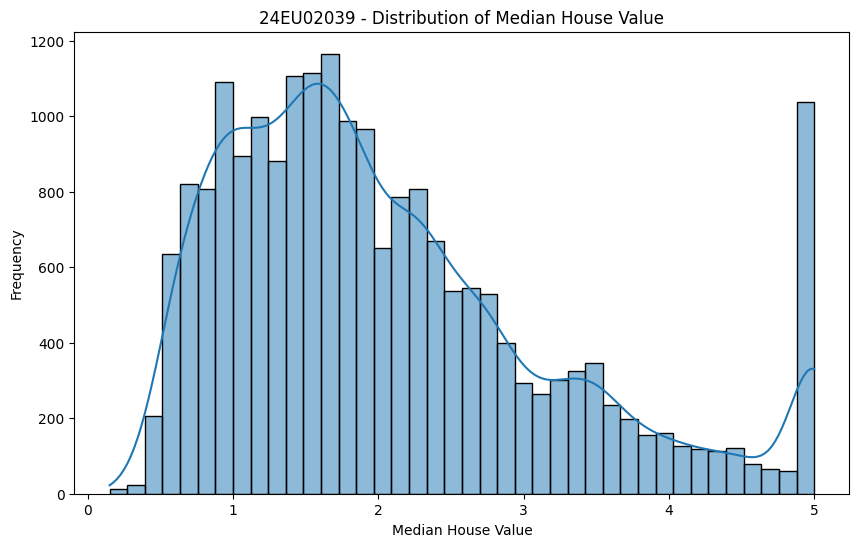


6. CORRELATION MATRIX
--------------------------------------------------
             MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc         1.00     -0.12      0.33      -0.06        0.00      0.02   
HouseAge      -0.12      1.00     -0.15      -0.08       -0.30      0.01   
AveRooms       0.33     -0.15      1.00       0.85       -0.07     -0.00   
AveBedrms     -0.06     -0.08      0.85       1.00       -0.07     -0.01   
Population     0.00     -0.30     -0.07      -0.07        1.00      0.07   
AveOccup       0.02      0.01     -0.00      -0.01        0.07      1.00   
Latitude      -0.08      0.01      0.11       0.07       -0.11      0.00   
Longitude     -0.02     -0.11     -0.03       0.01        0.10      0.00   
MedHouseVal    0.69      0.11      0.15      -0.05       -0.02     -0.02   

             Latitude  Longitude  MedHouseVal  
MedInc          -0.08      -0.02         0.69  
HouseAge         0.01      -0.11         0.11  
AveRooms         0.11

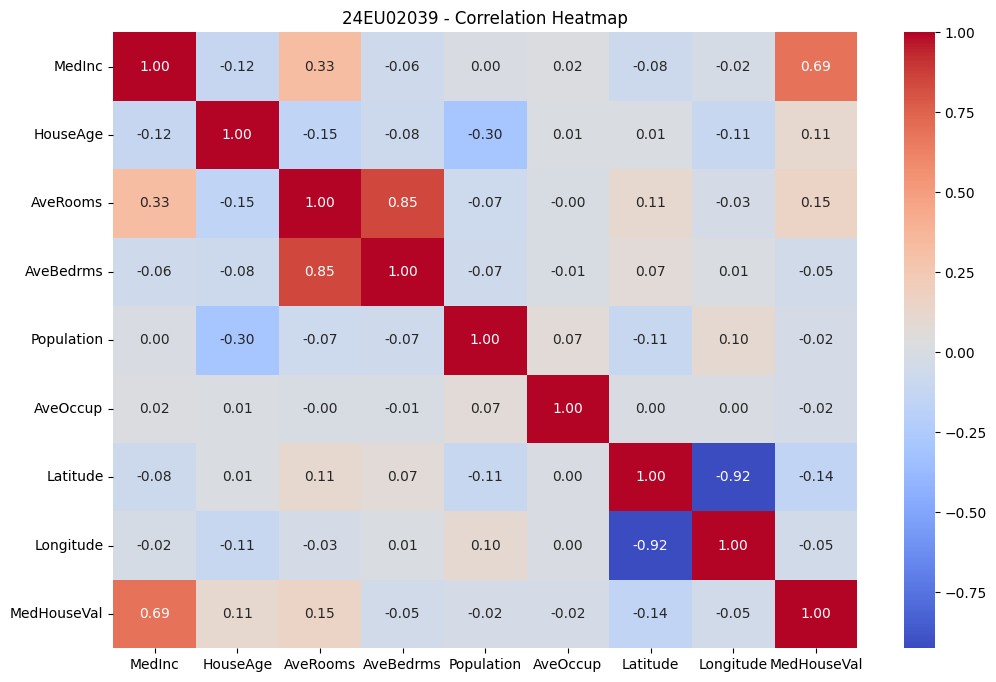


7. CORRELATION WITH TARGET
--------------------------------------------------
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64

8. FEATURES
--------------------------------------------------
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: MedHouseVal

9. TRAIN-TEST SPLIT
--------------------------------------------------
Training samples: 16512
Testing samples : 4128

10. FEATURE SCALING COMPLETED


                    MODEL EVALUATION

 Linear Regression
----------------------------------------
MAE      : 0.5332
MSE      : 0.5559
RMSE     : 0.7456
R2 Score : 0.5758

 Decision Tree
----------------------------------------
MAE      : 0.4332
MSE      : 0.4155
RMSE     : 0.6446
R2 Score : 0.6829

 Random Forest
----------------------------------------
MAE      : 

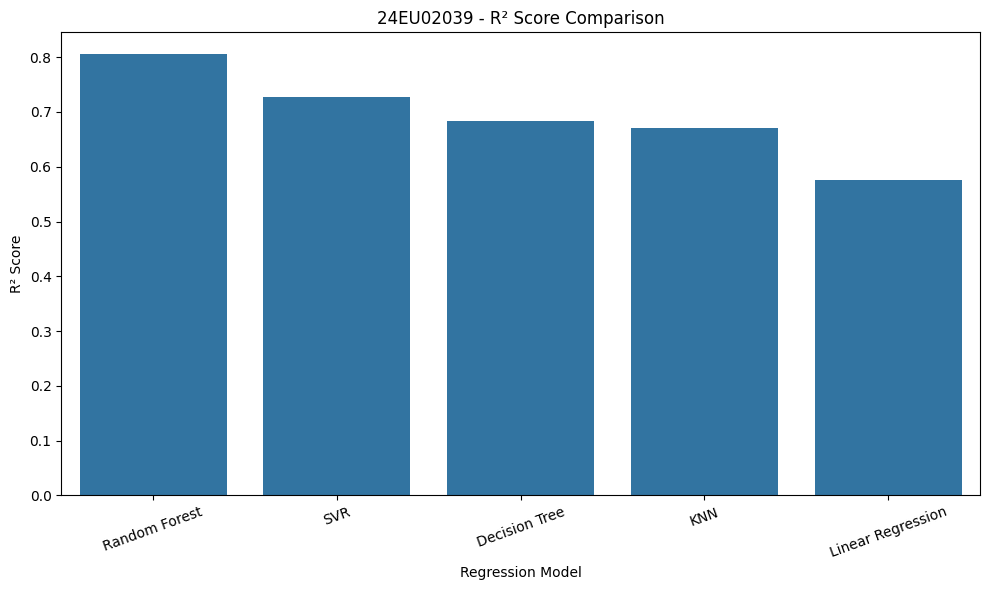

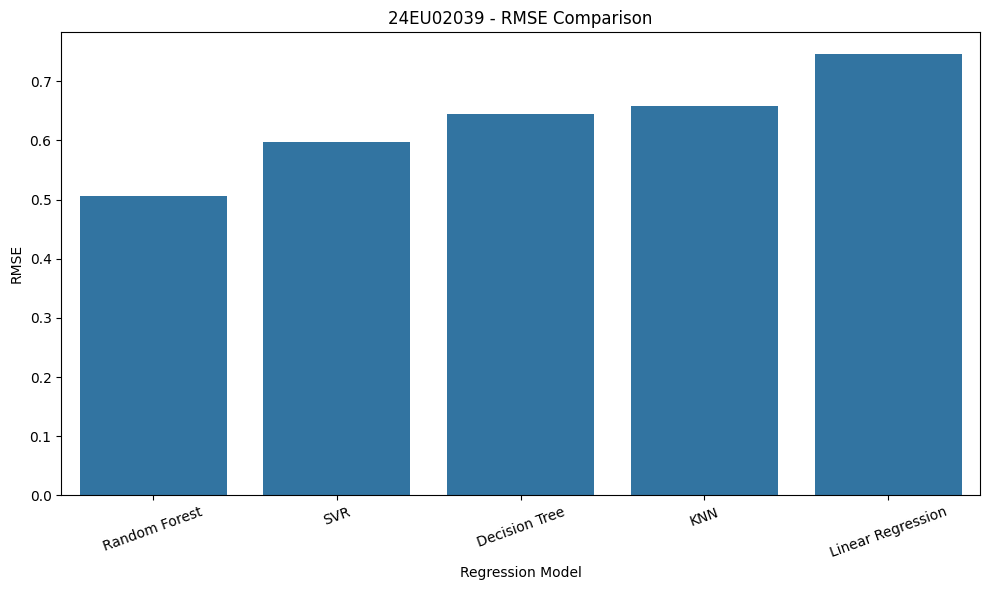



                       BEST MODEL
Best Model : Random Forest
R² Score   : 0.8051

ACTUAL VS PREDICTED VALUES
--------------------------------------------------
     Actual  Predicted
0   0.47700   0.509500
1   0.45800   0.741610
2   5.00001   4.923257
3   2.18600   2.529610
4   2.78000   2.273690
5   1.58700   1.646920
6   1.98200   2.376050
7   1.57500   1.669320
8   3.40000   2.772971
9   4.46600   4.913459
10  1.23200   1.138310
11  2.53900   1.998350
12  2.15100   1.711190
13  2.20500   1.805150
14  2.19800   2.419100
15  1.36200   1.588930
16  1.78400   1.976510
17  1.87500   1.775470
18  1.39800   1.498640
19  1.37500   0.894290


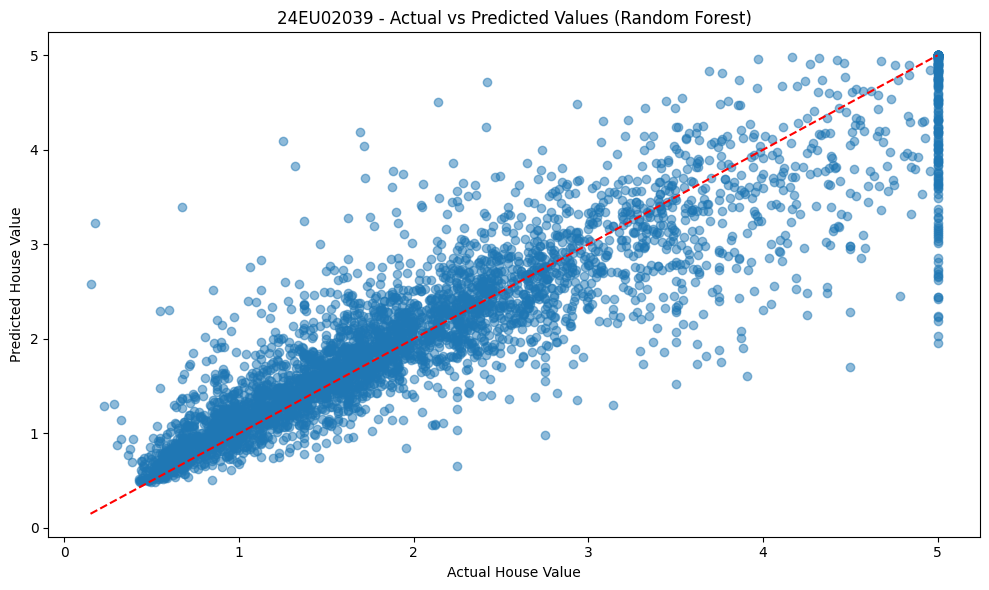

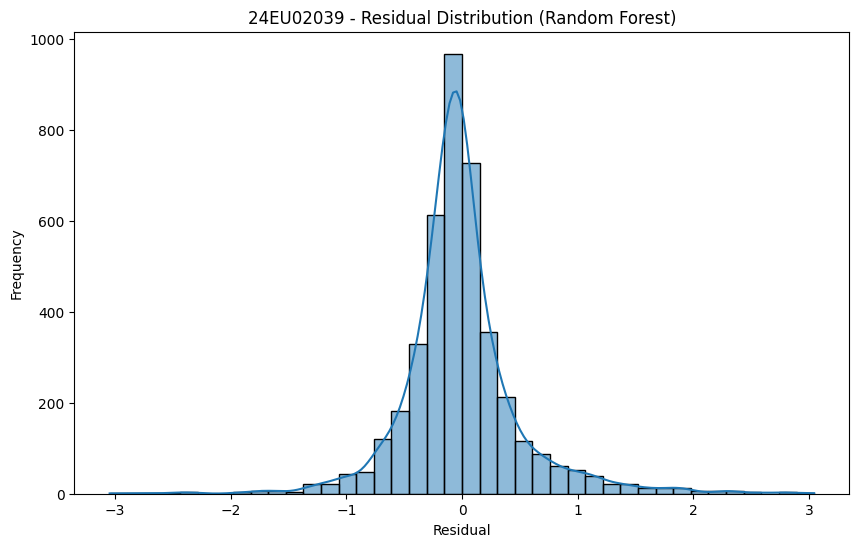

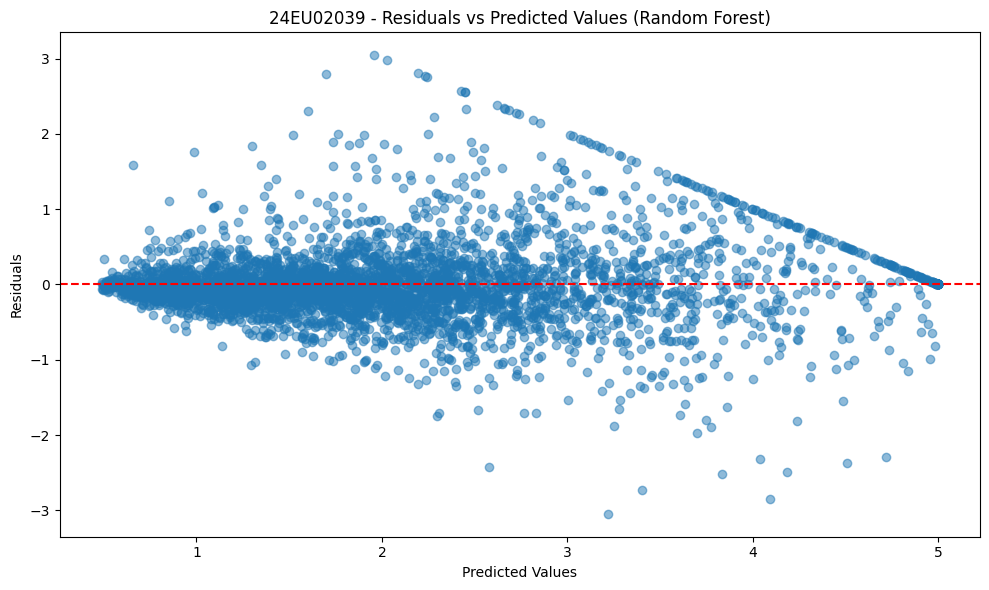


RANDOM FOREST FEATURE IMPORTANCE
--------------------------------------------------
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


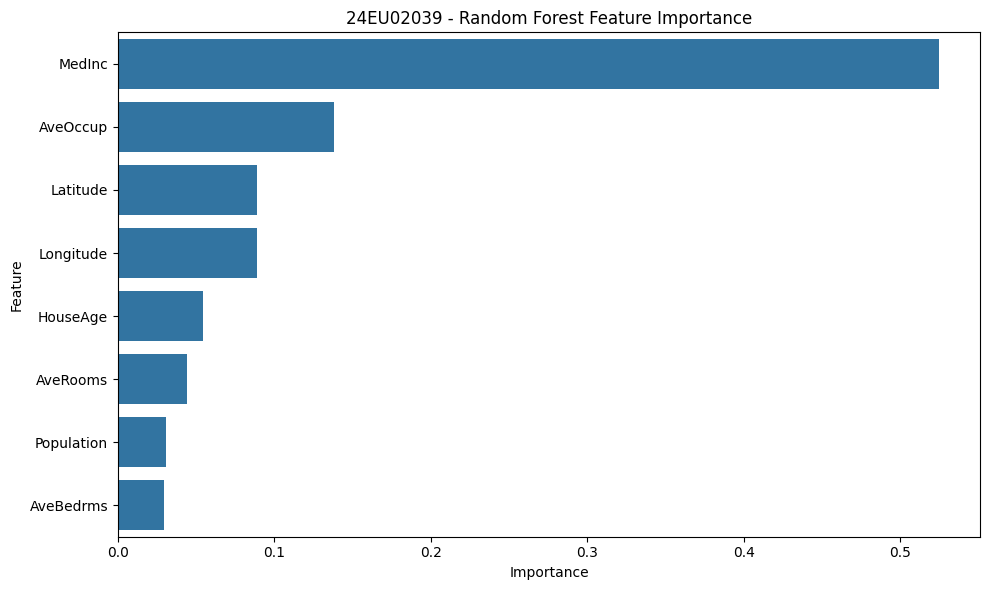



                    FINAL RESULTS
            Model    MAE    MSE   RMSE  R2 Score
    Random Forest 0.3275 0.2554 0.5053    0.8051
              SVR 0.3986 0.3570 0.5975    0.7276
    Decision Tree 0.4332 0.4155 0.6446    0.6829
              KNN 0.4462 0.4324 0.6576    0.6700
Linear Regression 0.5332 0.5559 0.7456    0.5758


                       CONCLUSION

The California Housing Dataset was used to perform
a regression task.

Target Variable:
MedHouseVal - Median House Value

Regression algorithms used:
1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. K-Nearest Neighbors Regression
5. Support Vector Regression

The dataset was divided into:
80% Training Data
20% Testing Data

The models were evaluated using:
- MAE
- MSE
- RMSE
- R² Score

Best performing model:
Random Forest

Best R² Score:
0.8051

A higher R² score indicates better predictive performance.

     CALIFORNIA HOUSING REGRESSION COMPLETED
                 24EU02039


In [3]:
# ============================================================
#       REGRESSION TASK - CALIFORNIA HOUSING DATASET
#       Register Number: 24EU02039
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("       REGRESSION TASK - CALIFORNIA HOUSING DATASET")
print("                Register No: 24EU02039")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

housing = fetch_california_housing(
    as_frame=True
)

df = housing.frame

print("\n1. FIRST 5 ROWS")
print("-" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)


# ------------------------------------------------------------
# 2. DATASET INFORMATION
# ------------------------------------------------------------

print("\n2. DATASET INFORMATION")
print("-" * 50)
df.info()


# ------------------------------------------------------------
# 3. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\n3. STATISTICAL SUMMARY")
print("-" * 50)
print(df.describe())


# ------------------------------------------------------------
# 4. MISSING VALUES
# ------------------------------------------------------------

print("\n4. MISSING VALUES")
print("-" * 50)
print(df.isnull().sum())


# ------------------------------------------------------------
# 5. DUPLICATES
# ------------------------------------------------------------

print("\n5. DUPLICATE ROWS")
print("-" * 50)
print("Duplicate rows:", df.duplicated().sum())


# ------------------------------------------------------------
# 6. TARGET DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df['MedHouseVal'],
    bins=40,
    kde=True
)

plt.title(
    '24EU02039 - Distribution of Median House Value'
)

plt.xlabel('Median House Value')
plt.ylabel('Frequency')

plt.show()


# ------------------------------------------------------------
# 7. CORRELATION HEATMAP
# ------------------------------------------------------------

correlation = df.corr()

print("\n6. CORRELATION MATRIX")
print("-" * 50)
print(correlation.round(2))

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    '24EU02039 - Correlation Heatmap'
)

plt.show()


# ------------------------------------------------------------
# 8. FEATURE-TARGET CORRELATION
# ------------------------------------------------------------

print("\n7. CORRELATION WITH TARGET")
print("-" * 50)

target_corr = (
    df.corr()['MedHouseVal']
    .drop('MedHouseVal')
    .sort_values(ascending=False)
)

print(target_corr)


# ------------------------------------------------------------
# 9. FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    'MedHouseVal',
    axis=1
)

y = df['MedHouseVal']

print("\n8. FEATURES")
print("-" * 50)
print(X.columns.tolist())

print("\nTarget: MedHouseVal")


# ------------------------------------------------------------
# 10. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n9. TRAIN-TEST SPLIT")
print("-" * 50)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 11. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\n10. FEATURE SCALING COMPLETED")


# ------------------------------------------------------------
# 12. CREATE REGRESSION MODELS
# ------------------------------------------------------------

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=5
        ),

    "SVR":
        SVR(
            kernel='rbf'
        )
}


# ------------------------------------------------------------
# 13. TRAIN AND EVALUATE MODELS
# ------------------------------------------------------------

results = []
predictions = {}

print("\n")
print("=" * 70)
print("                    MODEL EVALUATION")
print("=" * 70)

for name, model in models.items():

    if name in [
        "Linear Regression",
        "KNN",
        "SVR"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

    predictions[name] = y_pred

    print("\n", name)
    print("-" * 40)
    print("MAE      :", round(mae, 4))
    print("MSE      :", round(mse, 4))
    print("RMSE     :", round(rmse, 4))
    print("R2 Score :", round(r2, 4))


# ------------------------------------------------------------
# 14. MODEL COMPARISON
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

print("\n")
print("=" * 70)
print("                    MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 15. GRAPH - R2 SCORE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title(
    '24EU02039 - R² Score Comparison'
)

plt.xlabel('Regression Model')
plt.ylabel('R² Score')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. GRAPH - RMSE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title(
    '24EU02039 - RMSE Comparison'
)

plt.xlabel('Regression Model')
plt.ylabel('RMSE')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 17. BEST MODEL
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']

best_predictions = predictions[
    best_model_name
]

print("\n")
print("=" * 70)
print("                       BEST MODEL")
print("=" * 70)

print("Best Model :", best_model_name)
print("R² Score   :", round(best_r2, 4))


# ------------------------------------------------------------
# 18. ACTUAL VS PREDICTED
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_predictions
})

print("\nACTUAL VS PREDICTED VALUES")
print("-" * 50)
print(comparison.head(20))


# ------------------------------------------------------------
# 19. GRAPH - ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--'
)

plt.title(
    f'24EU02039 - Actual vs Predicted Values ({best_model_name})'
)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 20. RESIDUAL ANALYSIS
# ------------------------------------------------------------

residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title(
    f'24EU02039 - Residual Distribution ({best_model_name})'
)

plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.show()


# ------------------------------------------------------------
# 21. RESIDUALS VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title(
    f'24EU02039 - Residuals vs Predicted Values ({best_model_name})'
)

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 22. RANDOM FOREST FEATURE IMPORTANCE
# ------------------------------------------------------------

rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nRANDOM FOREST FEATURE IMPORTANCE")
print("-" * 50)
print(feature_importance)


# ------------------------------------------------------------
# 23. GRAPH - FEATURE IMPORTANCE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title(
    '24EU02039 - Random Forest Feature Importance'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 24. FINAL RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("                    FINAL RESULTS")
print("=" * 70)

final_results = results_df.copy()

final_results['MAE'] = final_results['MAE'].round(4)
final_results['MSE'] = final_results['MSE'].round(4)
final_results['RMSE'] = final_results['RMSE'].round(4)
final_results['R2 Score'] = final_results['R2 Score'].round(4)

print(
    final_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 25. CONCLUSION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("                       CONCLUSION")
print("=" * 70)

print(f"""
The California Housing Dataset was used to perform
a regression task.

Target Variable:
MedHouseVal - Median House Value

Regression algorithms used:
1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. K-Nearest Neighbors Regression
5. Support Vector Regression

The dataset was divided into:
80% Training Data
20% Testing Data

The models were evaluated using:
- MAE
- MSE
- RMSE
- R² Score

Best performing model:
{best_model_name}

Best R² Score:
{best_r2:.4f}

A higher R² score indicates better predictive performance.
""")

print("=" * 70)
print("     CALIFORNIA HOUSING REGRESSION COMPLETED")
print("                 24EU02039")
print("=" * 70)
